$\frac{d^2y}{dx^2}=-y^r-\frac{2}{x}\frac{dy}{dx}$   
Let's $y=y_1$ and $\frac{dy}{dx}=\frac{dy_1}{dx}=y_2$   
Therefore,   
$\frac{dy_1}{dx}=y_2$   
$\frac{dy_2}{dx}=-y_1^r-\frac{2}{x}y_2$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.integrate import solve_ivp

In [2]:
# Use serif fonts for publication-quality output
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5

# Tick formatting (inward-facing, all sides)
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['ytick.major.width'] = 1.2

In [3]:
def lane_emden(x, y, r):
    """
    Defines the Lane-Emden equation as a system of first-order ODEs.
    y = [y, y']
    """
    y1, y2 = y
    
    # Prevent fractional powers of negative numbers if solver overshoots the root
    y1_val = np.maximum(y1, 0.0)

    dy1_dx = y2
    dy2_dx = -y1_val**r - (2 / x) * y2

    return [dy1_dx, dy2_dx]


# Event function to stop integration when the first root is reached (y = 0)
def first_root(x, y, r):
    return y[0]
first_root.terminal = True
first_root.direction = -1

In [4]:
# Initial Conditions
y0 = [1.0, 0.0]
x0 = 1e-6   # Avoid x=0 due to singularity, use a small step x0
x_max = 20.0

# Constants
h = 6.62607015e-34
c = 299792458
G = 6.67430e-11
m_u = 1.66053906892e-27
mu_e = 2
M_sun = 1.988475e30

Let's define $x_1$ as the first root and $A$ as $A = -x_{1}^2\left[ \frac{dy}{dx} \right]_{x = x_{1}}$ respectively. 

In [5]:
# Define pairs of (numeric value for ODE solver, LaTeX string for legend)
r_configs = [
    (0,          r'$r = 0$'),
    (1,          r'$r = 1$'),
    (1.5,        r'$r = \frac{3}{2}$'),
    (2,          r'$r = 2$'),
#   (2.5,        r'$r = 2.5$'),
    (3,          r'$r = 3$'),
    (4,          r'$r = 4$'),
    (5,          r'$r = 5$'),
    (6,          r'$r = 6$'),
#   (np.sqrt(2), r'$r = \sqrt{2}$'),
#   (-1,         r'$r = -1$'),
#   (-10,        r'$r = -10$')
]

r          | First Root (x_1)          | A = -x_1^2 * dy/dx       
------------------------------------------------------------
0.000      | 2.44949                   | 4.89898                  
1.000      | 3.14159                   | 3.14159                  
1.500      | 3.65375                   | 2.71406                  
2.000      | 4.35287                   | 2.41105                  
3.000      | 6.89685                   | 2.01824                  
4.000      | 14.97155                  | 1.79723                  
5.000      | No root found in range    | -                        
6.000      | No root found in range    | -                        


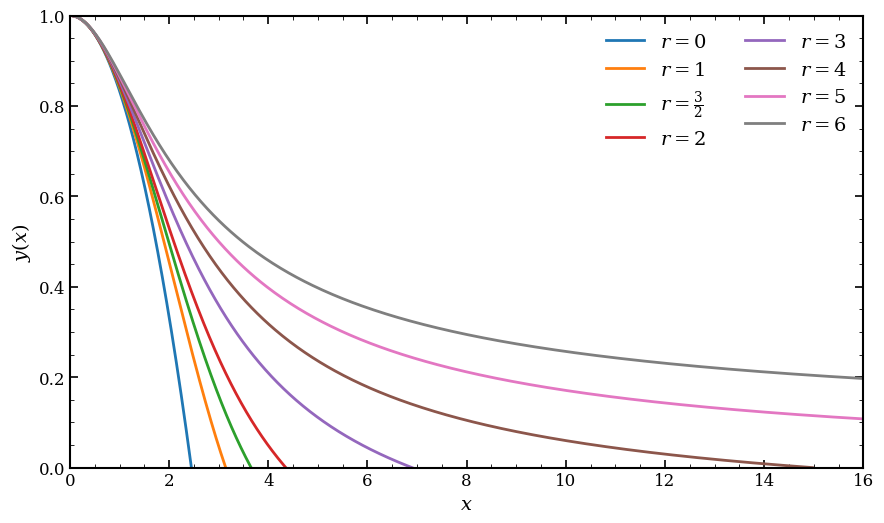

In [6]:
# Setup the plot
factor = 1.8
fig, ax = plt.subplots(figsize=(factor*5, factor*3))

# Print header for the mathematical properties
print(f"{'r':<10} | {'First Root (x_1)':<25} | {'A = -x_1^2 * dy/dx':<25}")
print("-" * 60)

for r, label_str in r_configs:
    # Solve the IVP
    sol = solve_ivp(lane_emden, [x0, x_max], y0, method='RK45', args=(r, ),
                    events=first_root, dense_output=True,
                    rtol=1e-10, atol=1e-10)
    
    if sol.success and len(sol.t_events[0]) > 0:
        x_1 = sol.t_events[0][0]
        dy_dx_x_1 = sol.y_events[0][0][1]
        
        r_display = "sqrt(2)" if np.isclose(r, np.sqrt(2)) else f"{r:<10.3f}"
        if r == 3: # for the calculation of Chandresekhar Mass
            A_r3 = -x_1**2 * dy_dx_x_1
        print(f"{r_display:<10} | {x_1:<25.5f} | {-x_1**2 * dy_dx_x_1:<25.5f}")
    else:
        r_display = "sqrt(2)" if np.isclose(r, np.sqrt(2)) else f"{r:<10.3f}"
        print(f"{r_display:<10} | {'No root found in range':<25} | {'-':<25}")

    x = np.linspace(x0, sol.t[-1], 500)
    y = sol.sol(x)[0]
    y = np.maximum(y, 0.0)  # Replace any negative overshoot values with 0.0 for clean graphing

    ax.plot(x, y, label=label_str, linewidth=2)

# Format the plot
ax.set_xlim(0, 16)
ax.set_ylim(0, 1)
ax.set_xlabel(r'$x$', fontsize=14)
ax.set_ylabel(r'$y(x)$', fontsize=14)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.legend(frameon=False, fontsize=14, loc='upper right', ncol=2)
plt.tight_layout()
plt.savefig('./IMGs/lane_emden_theta.png', bbox_inches='tight', dpi=1200)
plt.show()

In [7]:
M_ch = (np.sqrt(3/32)*
        (1/np.pi)*
        A_r3*
        ((h*c/G)**(3/2))*
        (1/(m_u*mu_e)**2)) / M_sun
print(f"Chandresekhar Limit = {M_ch} solar mass")

Chandresekhar Limit = 1.4562498507981454 solar mass


In [8]:
print(M_ch*mu_e**2)

5.824999403192582
